In [62]:
from random import random
import math
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

NUM_OF_GENERATED_RANDOM_VALUES = 1000
LAMBDA = 5

In [63]:
def generate_poisson_random_variable(lambd: int) -> int:
    exp_lambda = math.exp(-lambd)
    p = 1
    n = 0
    while(p > exp_lambda):
        p *= random()
        n += 1
    return n - 1

lambda_: int = LAMBDA #int(input("Print a value of lambda: "))
a: list[int] = []
for i in range(NUM_OF_GENERATED_RANDOM_VALUES):
    a.append(generate_poisson_random_variable(lambda_))

In [64]:
def count_mean(arr: list) -> float:
    return sum(arr) / len(arr)

def count_variation(arr: list) -> float:
    mean = count_mean(arr)
    return sum((x - mean) ** 2 for x in arr) / (len(arr) - 1)

expected_value_generated = count_mean(a)
variance_generated = count_variation(a)

print(f"Mean of generated sample: {expected_value_generated}")
print(f"Mean of Poisson distribution: {lambda_}")
print(f"Variance of generated sample: {variance_generated}")
print(f"Variance of Poisson distribution: {lambda_}")

Mean of generated sample: 5.019
Mean of Poisson distribution: 5
Variance of generated sample: 4.751390390390391
Variance of Poisson distribution: 5


In [65]:
def poisson_pmf(lambda_: int, k: int) -> float:
    return (lambda_ ** k) * math.exp(-lambda_) / math.factorial(k)

def get_statistic_chi_square_poisson(arr: list, lambda_: int) -> float:
    num_of_elements = max(arr)
    n = len(arr)
    chi = 0
    for i in range(num_of_elements):
        nu = arr.count(i)
        np = n * poisson_pmf(lambda_, i)
        chi += (nu - np) ** 2 / np
    return chi

chi_square_statistic = get_statistic_chi_square_poisson(a, lambda_)
chi_square_critical = chi2.isf(0.05, max(a)-1)

print(f"Statistic of chi-square: {chi_square_statistic}")
print(f"Critical Chi-Square value with p=0.05 is {chi_square_critical}")
if chi_square_statistic < chi_square_critical:
    print("Distribution of generated sample is Poisson")
else:
    print("Distribution of generated sample is NOT Poisson")

Statistic of chi-square: 8.15565187928523
Critical Chi-Square value with p=0.05 is 21.02606981748307
Distribution of generated sample is Poisson


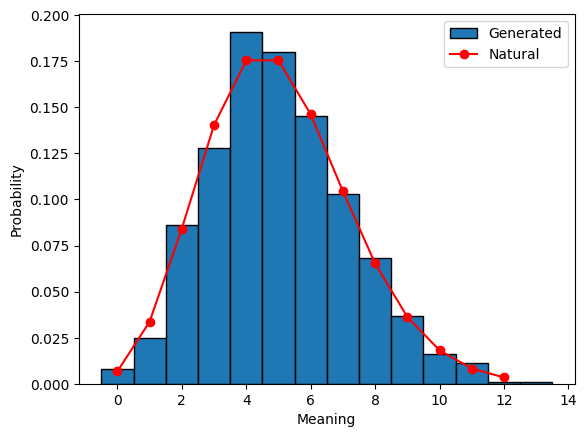

In [66]:
k = np.arange(0, max(a))
# probs = poisson.pmf(k, lambda_)
probs = np.array([])
for i in k:
    probs = np.append(probs, poisson_pmf(lambda_, i))
bins = np.arange(min(a) - 0.5, max(a) + 1.5, 1)
plt.hist(a, bins=bins, density=True, edgecolor='black', label='Generated')
plt.plot(k, probs, 'o-', color='red', label=f'Natural')

plt.xlabel("Meaning")
plt.ylabel("Probability")
plt.legend()
plt.show()

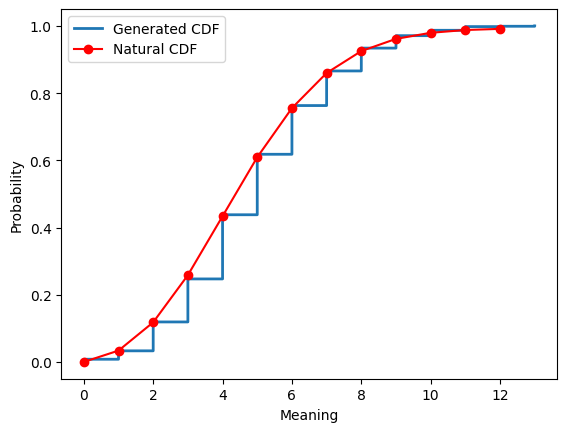

In [68]:
a.sort()
k = np.arange(0, max(a))
y = np.arange(1, len(a)+1) / len(a)
pmf_arr = []
probs = np.array([0])
for i in k[1:]:
    pmf = poisson_pmf(lambda_, i)
    probs = np.append(probs, probs[i-1] + pmf)
bins = np.arange(min(a) - 0.5, max(a) + 1.5, 1)
plt.step(a, y, where='post', label='Generated CDF', lw=2)
plt.plot(k, probs, 'o-', color='red', label=f'Natural CDF')

plt.xlabel("Meaning")
plt.ylabel("Probability")
plt.legend()
plt.show()